In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
df = pd.read_csv("housing.csv")

In [40]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [41]:
# Number of rows

row , col = df.shape
print(f"Rows : {row}  Columns : {col}")

Rows : 20640  Columns : 10


In [42]:
# Feature names

df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [43]:
# Data types

df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [44]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Data Cleaning

In [45]:
# Missing values

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [46]:
df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [47]:
# Duplicate rows

duplicated_rows = df[df.duplicated()]
print(duplicated_rows)

Empty DataFrame
Columns: [longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity]
Index: []


In [48]:
duplicated_col = df.T.duplicated()
print(duplicated_col)

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms        False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool


In [49]:
# data type

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [50]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [51]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Clean data

In [136]:
print(df['total_bedrooms'].head(20))

0      129.0
1     1106.0
2      190.0
3      235.0
4      280.0
5      213.0
6      489.0
7      687.0
8      665.0
9      707.0
10     434.0
11     752.0
12     474.0
13     191.0
14     626.0
15     283.0
16     347.0
17     293.0
18     455.0
19     298.0
Name: total_bedrooms, dtype: float64


In [137]:
print(df['total_bedrooms'].unique()[:20])

[ 129. 1106.  190.  235.  280.  213.  489.  687.  665.  707.  434.  752.
  474.  191.  626.  283.  347.  293.  455.  298.]


In [53]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(med)

In [138]:
df['total_bedrooms'] = pd.to_numeric(df['total_bedrooms'],errors='coerce')

In [139]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [140]:
print(df['total_bedrooms'].dtype)
print(df['total_bedrooms'].isnull().sum())

float64
0


In [141]:
df.isna().sum()

housing_age                   0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
income                        0
house_value                   0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

# Data Visualization

In [55]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


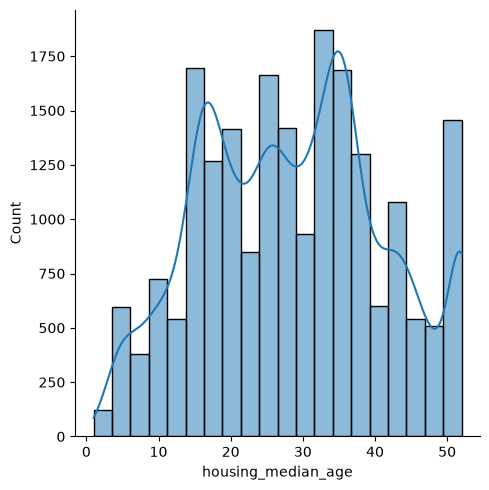

In [56]:
sns.displot(df['housing_median_age'], kde=True, bins=20)

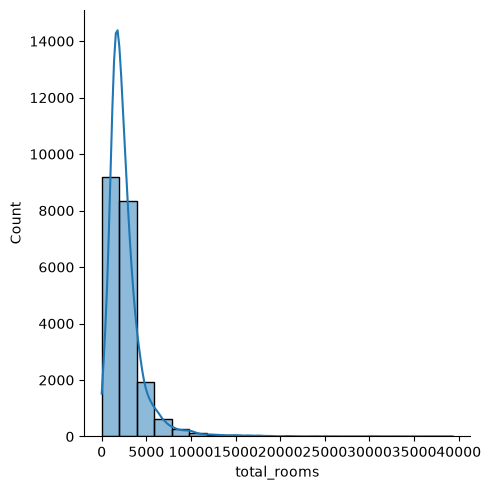

In [57]:
sns.displot(df['total_rooms'], kde=True, bins=20)

TypeError: Invalid object type at position 290

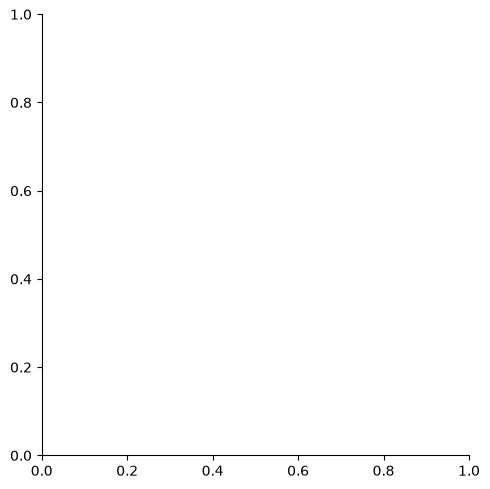

In [58]:
sns.displot(df['total_bedrooms'], kde=True, bins=20)

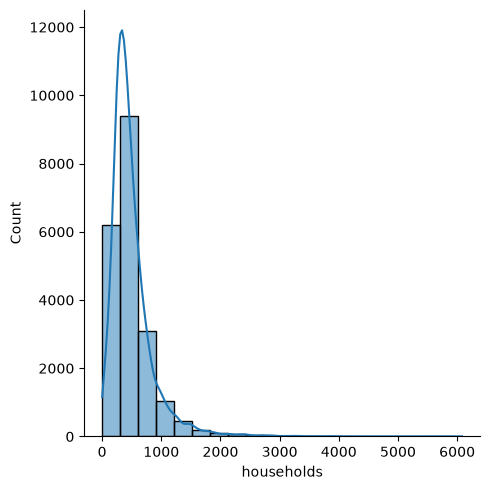

In [59]:
sns.displot(df['households'], kde=True, bins=20)

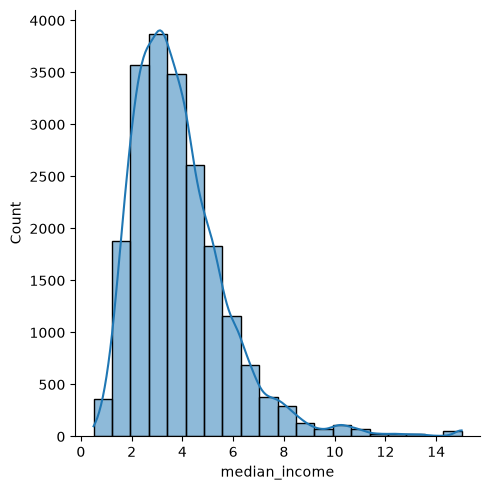

In [60]:
sns.displot(df['median_income'], kde=True, bins=20)

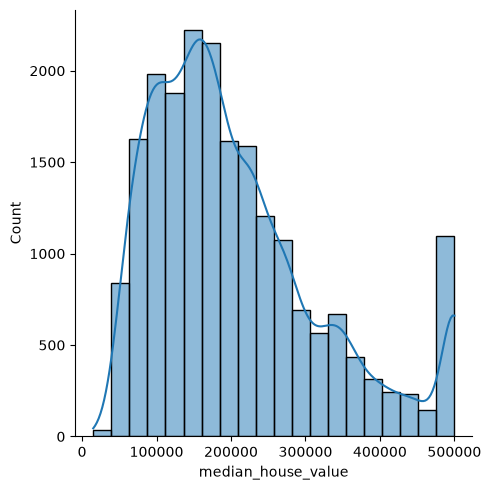

In [61]:
sns.displot(df['median_house_value'], kde=True, bins=20)

<Axes: xlabel='median_house_value'>

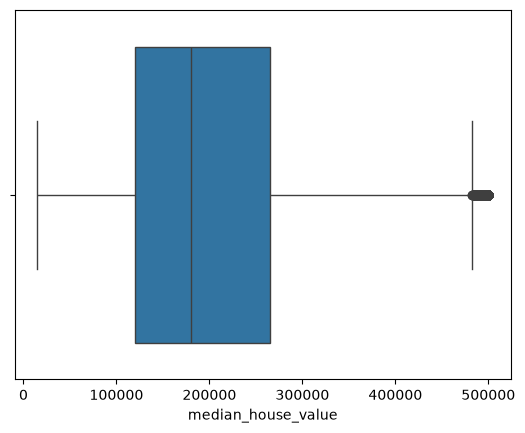

In [62]:
sns.boxplot(x=df['median_house_value'], data=df)

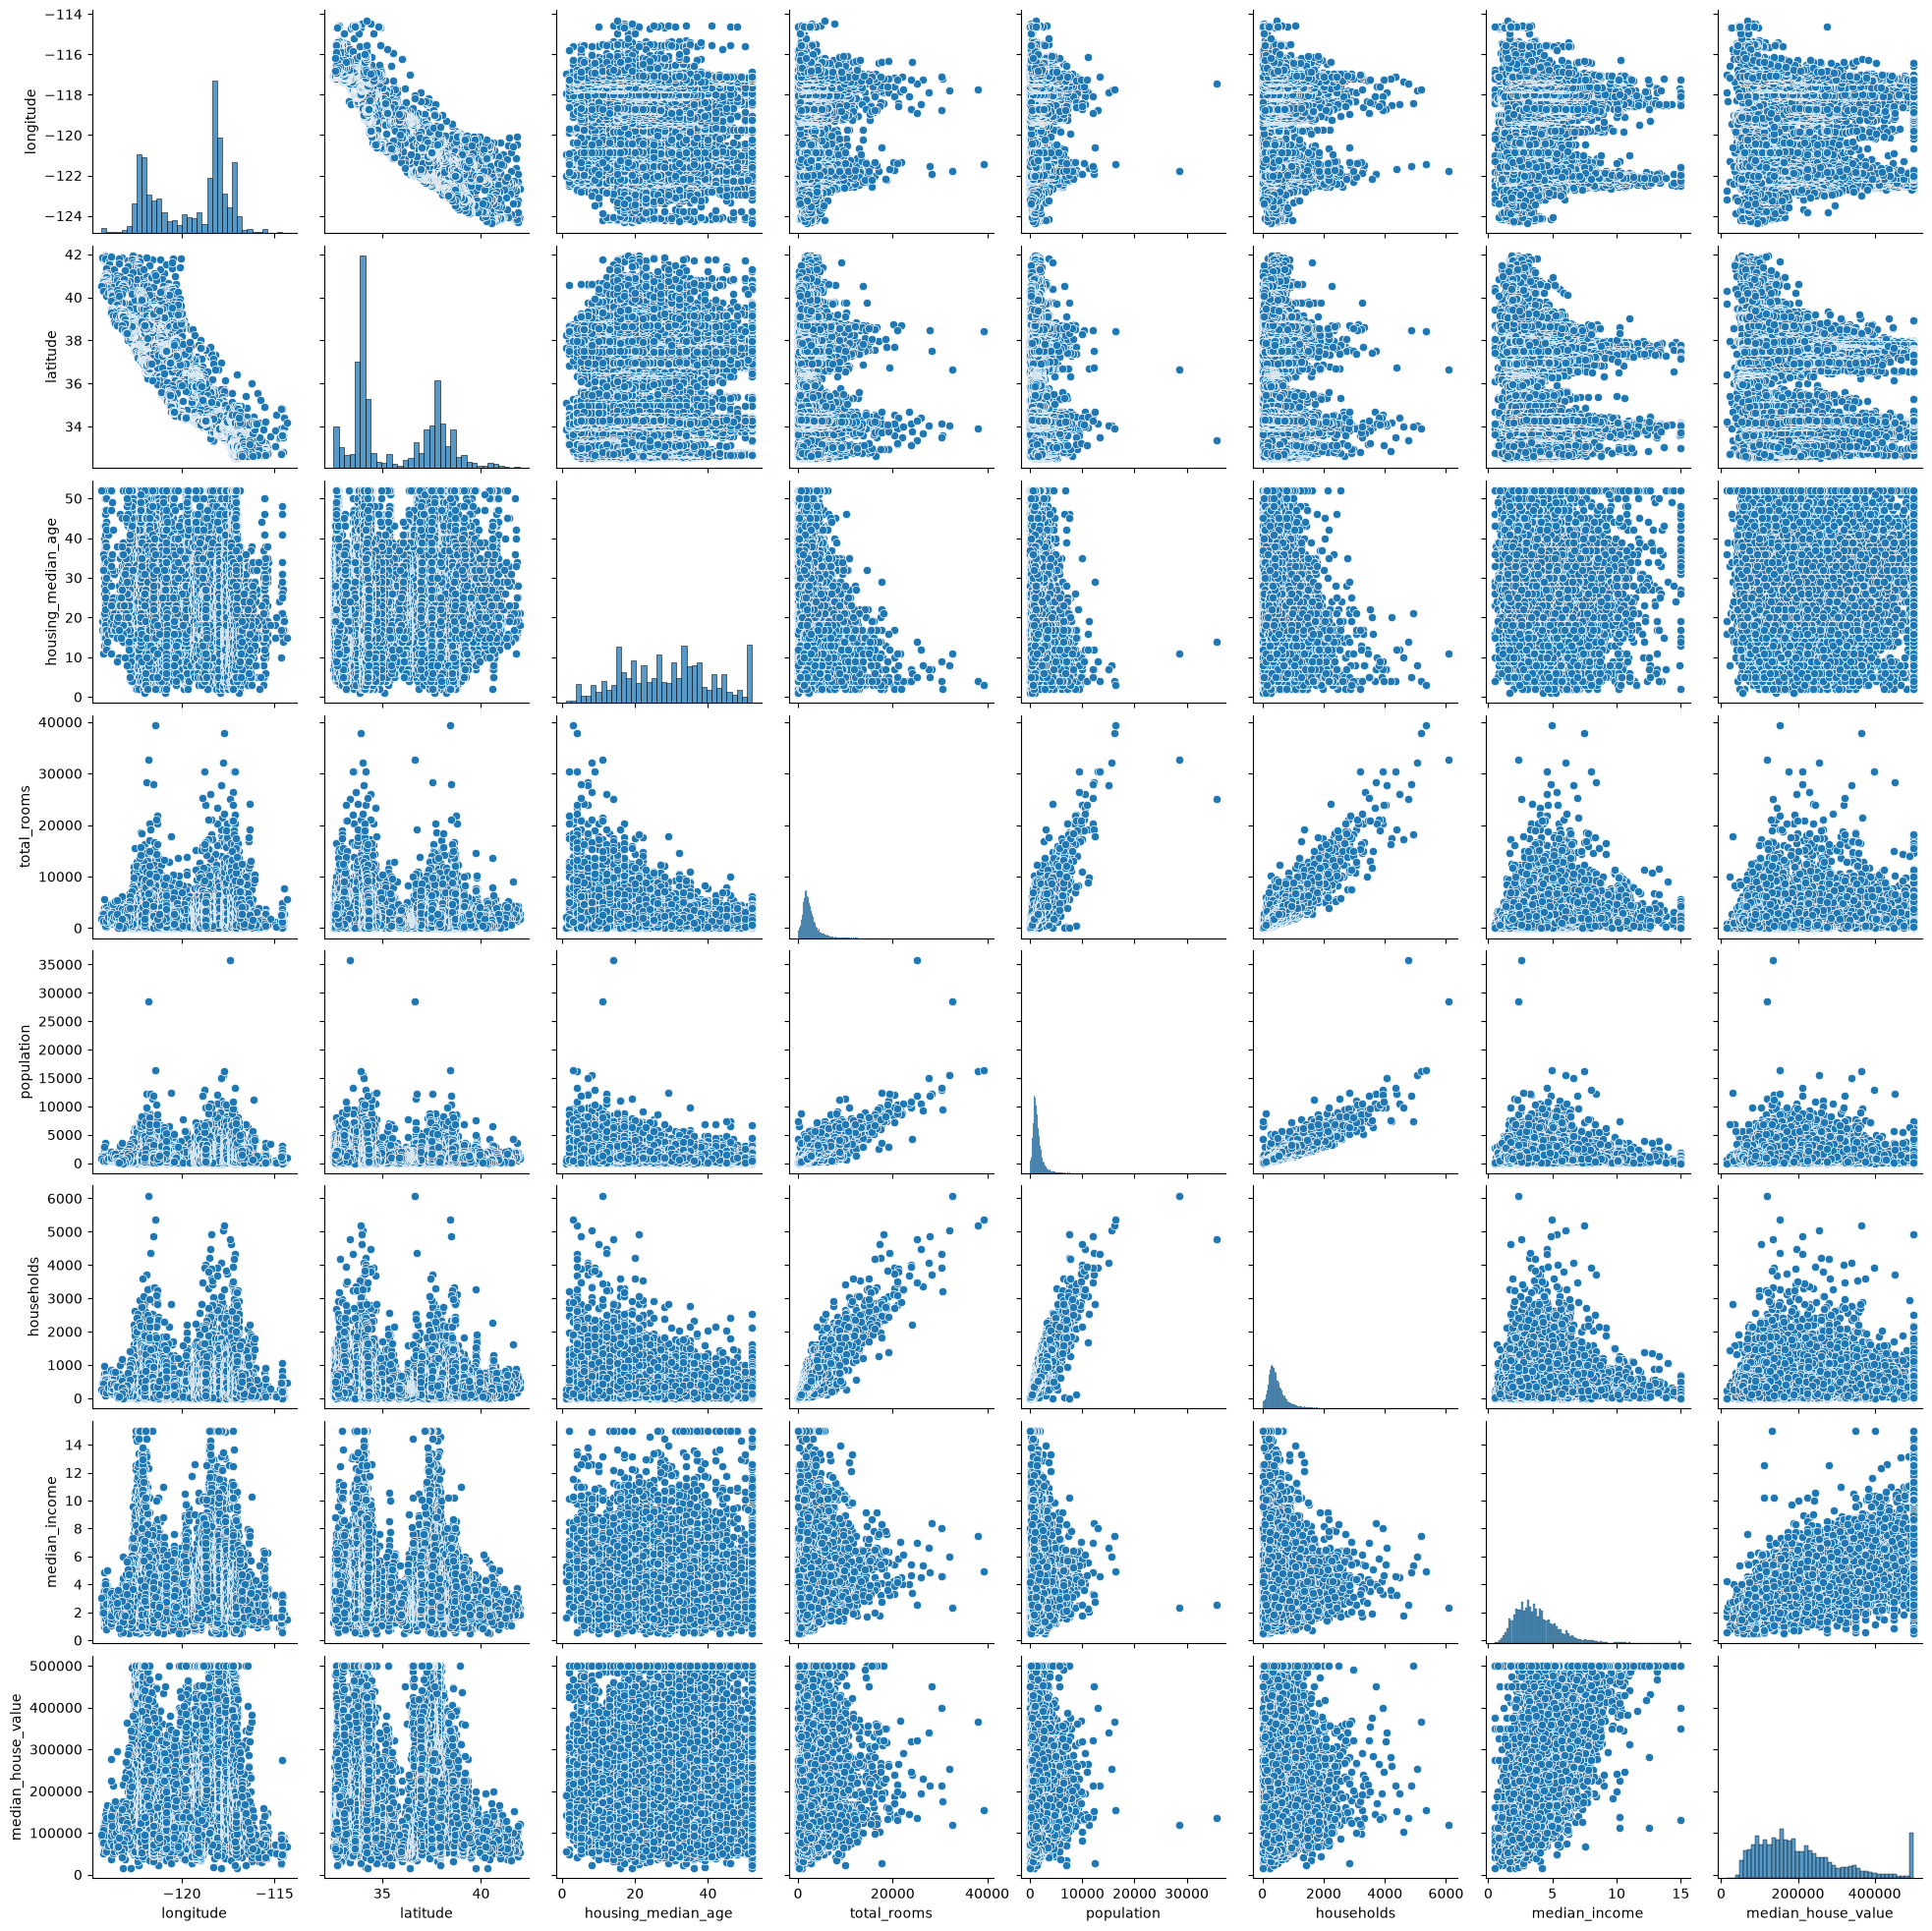

In [63]:
sns.pairplot(df)

TypeError: Invalid object type at position 290

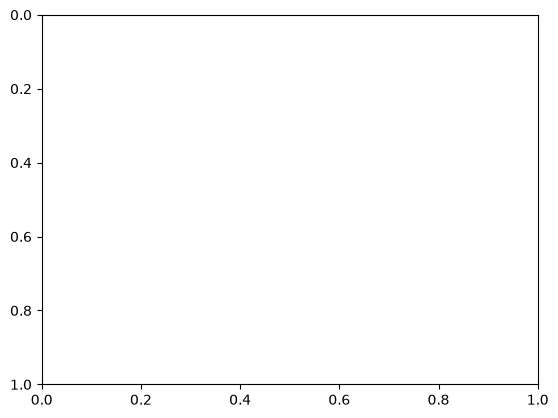

In [64]:
sns.scatterplot(x=df['total_rooms'], y=df['total_bedrooms'], hue=df['median_house_value'])

<Axes: xlabel='median_income', ylabel='median_house_value'>

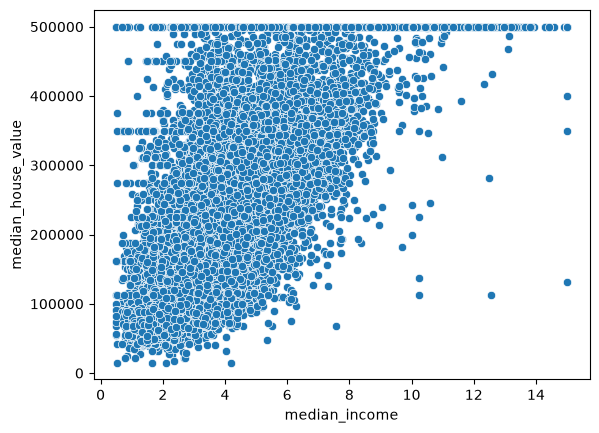

In [65]:
sns.scatterplot(x=df['median_income'], y=df['median_house_value'])

<Axes: >

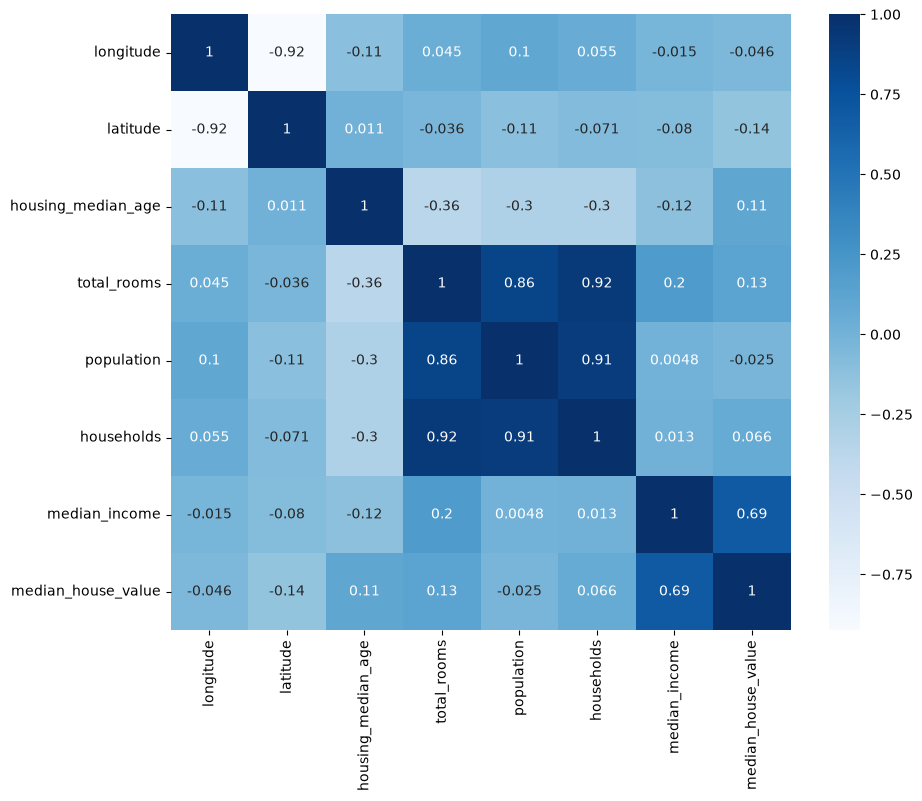

In [66]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr( numeric_only = True), annot=True, cmap="Blues")

# 

Transform the data

In [67]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [68]:
# removing the unnecessary columns from the data

df.drop(["longitude", "latitude"], axis=1, inplace=True)

In [69]:
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [70]:
# rename

df = df.rename(columns = {"housing_median_age" : "housing_age"})
df.head()

,housing_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [94]:
df = df.rename(columns = {"median_house_value" : "house_value"})
df.head()

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [72]:
df = df.rename(columns = {"median_income" : "income"})
df.head()

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# One hot encoding

#### It is a technique used to represent categorical variables as numerical data. It creates a new binary column for each unique category in a categorical variable. Each row has a 1 in the column for the category it belongs to, and a 0 in all other columns.

<Axes: xlabel='ocean_proximity', ylabel='count'>

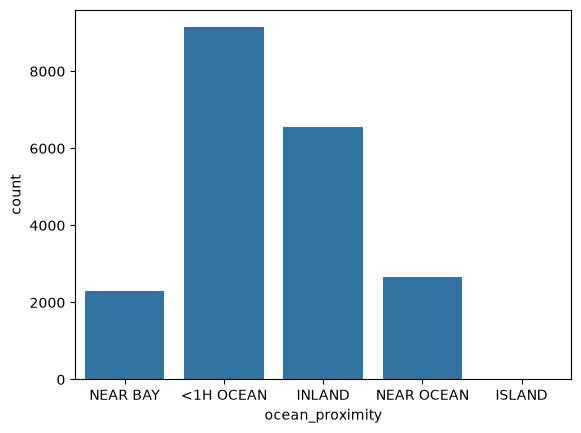

In [73]:
sns.countplot(x=df['ocean_proximity'], data=df)

In [74]:
df = pd.get_dummies(df,columns=["ocean_proximity"],drop_first=True,dtype=int)
df.head()

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [75]:
df.shape

(20640, 11)

In [76]:
df.isnull().sum()

housing_age                   0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
income                        0
house_value                   0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

# Feature scaling

In [83]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [84]:
from sklearn.preprocessing import StandardScaler

In [127]:
numerical_df = df[['housing_age','total_rooms', 'total_bedrooms', 'population', 'households', 'income','house_value']]

In [128]:
scaler = StandardScaler()

In [129]:
sc_df = scaler.fit(numerical_df)

In [130]:
scaled_df = sc_df.transform(numerical_df)

In [131]:
new_df_lite = pd.DataFrame(data = scaled_df, columns=numerical_df.columns)

In [132]:
new_df_lite.head(3)

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631
1,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693


In [133]:
df.head(3)

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0


In [134]:
cat_df = df[['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']]

In [142]:
new_df = pd.concat([new_df_lite, cat_df], axis=1)
new_df.head()

,housing_age,total_rooms,total_bedrooms,population,households,income,house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,0,0,1,0
1,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,0,0,1,0
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,0,0,1,0
3,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,0,0,1,0
4,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,0,0,1,0


# Split the data

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
X = new_df.drop("house_value", axis = 1)
y = new_df["house_value"]

In [145]:
X.head()

,housing_age,total_rooms,total_bedrooms,population,households,income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,0,0,1,0
1,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,0,0,1,0
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,0,0,1,0
3,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,0,0,1,0
4,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,0,0,1,0


In [146]:
y.head()

0    2.129631
1    1.314156
2    1.258693
3    1.165100
4    1.172900
Name: house_value, dtype: float64

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=20)

In [148]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16512, 10)
(16512,)
(4128, 10)
(4128,)


# Build the model

In [149]:
from sklearn.linear_model import LinearRegression

In [150]:
lr = LinearRegression()

In [151]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.13,-0.11, 0.2 ,..., 1.48, 0.02, 0.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['housing_age','total_rooms','total_bedrooms',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1698
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [152]:
lr_pred = lr.predict(X_test)

In [153]:
df1 = pd.DataFrame({"Y_test": y_test , "Y_pred" : lr_pred})
df1.head(3)

,Y_test,Y_pred
6111,-0.773495,-0.447601
17742,0.739597,0.644892
79,-0.654771,-0.356519


# R² Score

In [154]:
from sklearn.metrics import r2_score

In [155]:
r2 = r2_score(y_test, lr_pred)

In [157]:
print("R² Score : ", r2)

R² Score :  0.6287262669667171


# MAE

In [158]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, lr_pred)

print("MAE:", mae)

MAE: 0.44447838571217113


# Decision Tree Regression

In [165]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("Decision Tree")

d2 = r2_score(y_test, dt_pred)
print("R² Score : ", r2)

mae2 = mean_absolute_error(y_test, lr_pred)
print("MAE:", mae)

Decision Tree
R² Score :  0.6287262669667171
MAE: 0.44447838571217113


In [166]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R² Score": [r2, d2],
    "MAE": [mae, mae2]
})

print(comparison)

               Model  R² Score       MAE
0  Linear Regression  0.628726  0.444478
1      Decision Tree  0.481907  0.444478
